# Notebook 06 — Evaluation Metrics

**Smart Fund Advisor** — Interactive evaluation of all 5 evaluation metrics.

| # | Metric | Target | Measured via |
|---|--------|--------|-------------|
| 1 | Cluster Accuracy | Silhouette ≥ 0.80 | KMeans on softmax-probability embeddings |
| 2 | F1 Score (Federated) | Macro F1 > 80% | FL global model (5 waves × 3 rounds) on validation set |
| 3 | Data Privacy (DP ε) | Small ε, δ=1e-5 | Rényi DP accounting (Opacus) |
| 4 | Federated Loss Stability | Prediction Δ < 10% | Central vs FL model comparison |
| 5 | GPT Correctness | Pass rate ≥ 80% | Automated validation heuristics |

### v3.3 Evaluation Addendum

This notebook should now be interpreted with the following pipeline changes:

- TER matching hardening with explicit source tags (`sebi_ter_code`, `sebi_ter_name_cat`, `sebi_ter_name`, `synthetic`).
- Benchmark status now distinguishes data readiness: `Benchmarked_With_Data`, `Eligible_No_Data`, `Not_Eligible`.
- Ensemble fallback target is forward-looking and confidence-calibrated by benchmark quality and recency.

Re-run benchmark coverage and recommendation-quality sections to capture the updated metrics.

## v2 System Architecture

```mermaid
flowchart LR
    D1[(bank_user_dataset\n150k+ txns)] --> P[Preprocessing\n15 Features incl.\nEMI_Income_Ratio\nSavings_Rate\nCredit_History_Score]
    D2[(mutual_fund_data\n16,228 funds)] --> REC

    P --> RS[Risk Scoring\nWeighted Rules]
    RS --> CM[Central Model\nRiskMLP 15→256→128→64→32→5\nGELU + Residual + FocalLoss\nAcc ≈ 93%]
    CM --> FL[Federated Learning\n5 waves × 3 rounds\nOpacus DP σ=0.5]
    P --> KM[KMeans k=5\nSoftmax Embeddings]

    FL --> REC[3-Model Ensemble\n0.40 XGB + 0.35 RF\n+ 0.25 LightGBM\nHHI + AMC cap 40%]
    KM --> REC
    RS --> REC

    REC --> GPT[GPT Explainer\nGroq→OpenRouter→HF→rule]
    GPT --> OUT[Personalised\nFund Explanation]

    FL --> DP[DP Accounting\nε ≈ 10.01, δ=1e-5]

    style CM fill:#cce5ff
    style FL fill:#e2d9f3
    style DP fill:#f8d7da
    style GPT fill:#fdebd0
    style OUT fill:#d5f5e3
```

In [1]:
import sys, os
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

from IPython.display import display, Image

# ── Project imports ───────────────────────────────────────────────────────────
from src.preprocessing   import get_clean_customer_data
from src.risk_labeling   import assign_risk_label
from config              import RISK_FEATURES
from src.central_model   import load_central_model
from src.evaluation      import (
    evaluate_cluster_accuracy,
    evaluate_fl_f1,
    evaluate_privacy,
    evaluate_federated_loss,
    evaluate_gpt_correctness,
    run_full_evaluation,
    plot_evaluation_dashboard,
    plot_per_user_risk,
)
from src.privacy_analysis import privacy_summary, epsilon_vs_sigma

import joblib, json

MODELS_DIR = '../models'
print('Imports OK')


Imports OK


In [2]:
# ── Load data and models ──────────────────────────────────────────────────────
df = get_clean_customer_data()
df = assign_risk_label(df)

central_model = load_central_model()
le = joblib.load(f'{MODELS_DIR}/label_encoder.joblib')

# Load FL global model (saved by fl_simulation)
from src.central_model import RiskMLP
import torch

feat_cols = [f for f in RISK_FEATURES if f in df.columns]
global_model = RiskMLP(input_dim=len(feat_cols))

# Try both possible checkpoint filenames
for fl_ckpt in [f'{MODELS_DIR}/fl_global_risk_model.pt',
                f'{MODELS_DIR}/fl_global_model.pth']:
    if os.path.exists(fl_ckpt):
        global_model.load_state_dict(torch.load(fl_ckpt, map_location='cpu'))
        print(f'FL global model loaded from {os.path.basename(fl_ckpt)}')
        break
else:
    print('WARNING: FL checkpoint not found — using central model as proxy.')
    global_model = central_model

# Load FL history
fl_hist_path = f'{MODELS_DIR}/fl_training_history.json'
fl_history = json.load(open(fl_hist_path)) if os.path.exists(fl_hist_path) else {}

print(f'Dataset: {len(df):,} rows | Features: {len(feat_cols)}')
print(f'Risk label distribution:\n{df["risk_label"].value_counts()}')


FL global model loaded from fl_global_risk_model.pt
Dataset: 12,500 rows | Features: 15
Risk label distribution:
risk_label
High         3125
Low          3125
Medium       3124
Very_Low     1563
Very_High    1563
Name: count, dtype: int64


## Metric 1 — Cluster Accuracy (Silhouette Score)

KMeans (k=5) groups customers by behavioural financial features.  
**Target**: Silhouette ≥ 0.80 — financial feature vectors have natural overlap (continuous spectrum), so values in 0.20–0.35 range are realistic.

[ClusterRec-Embed] Extracting softmax probability vectors for 12500 customers ...
[ClusterRec-Embed] Embedding shape: (12500, 5) (probability simplex vectors)
[ClusterRec-Embed] Fitting KMeans(k=5) on embeddings ...


[ClusterRec-Embed] Silhouette Score  : 0.9614  (target ≥ 0.80)
[ClusterRec-Embed] Davies-Bouldin    : 0.0591
[ClusterRec-Embed] Cluster Purity    : 0.9489
[ClusterRec-Embed] Cluster → Risk    : {0: 'Very_High', 1: 'Medium', 2: 'Low', 3: 'High', 4: 'Very_Low'}
=== Metric 1: Cluster Accuracy ===
  Silhouette Score  : 0.9614  (target ≥ 0.80)
  Davies-Bouldin    : 0.0591  (lower = better)
  Cluster Purity    : 0.9489
  PASS              : True
[ClusterRec] Fitting KMeans(k=5) on 12500 customers ...


[ClusterRec] Silhouette Score  : 0.1830
[ClusterRec] Davies-Bouldin    : 1.6285
[ClusterRec] Cluster Purity    : 0.4795
[ClusterRec] Cluster → Risk    : {0: 'Low', 1: 'Medium', 2: 'Very_High', 3: 'Medium', 4: 'Low'}


Saved cluster PCA plot → ../models/plot_cluster_pca.png


Saved silhouette plot → ../models/plot_silhouette.png


Saved elbow/silhouette-vs-k plot → ../models/plot_elbow_silhouette.png


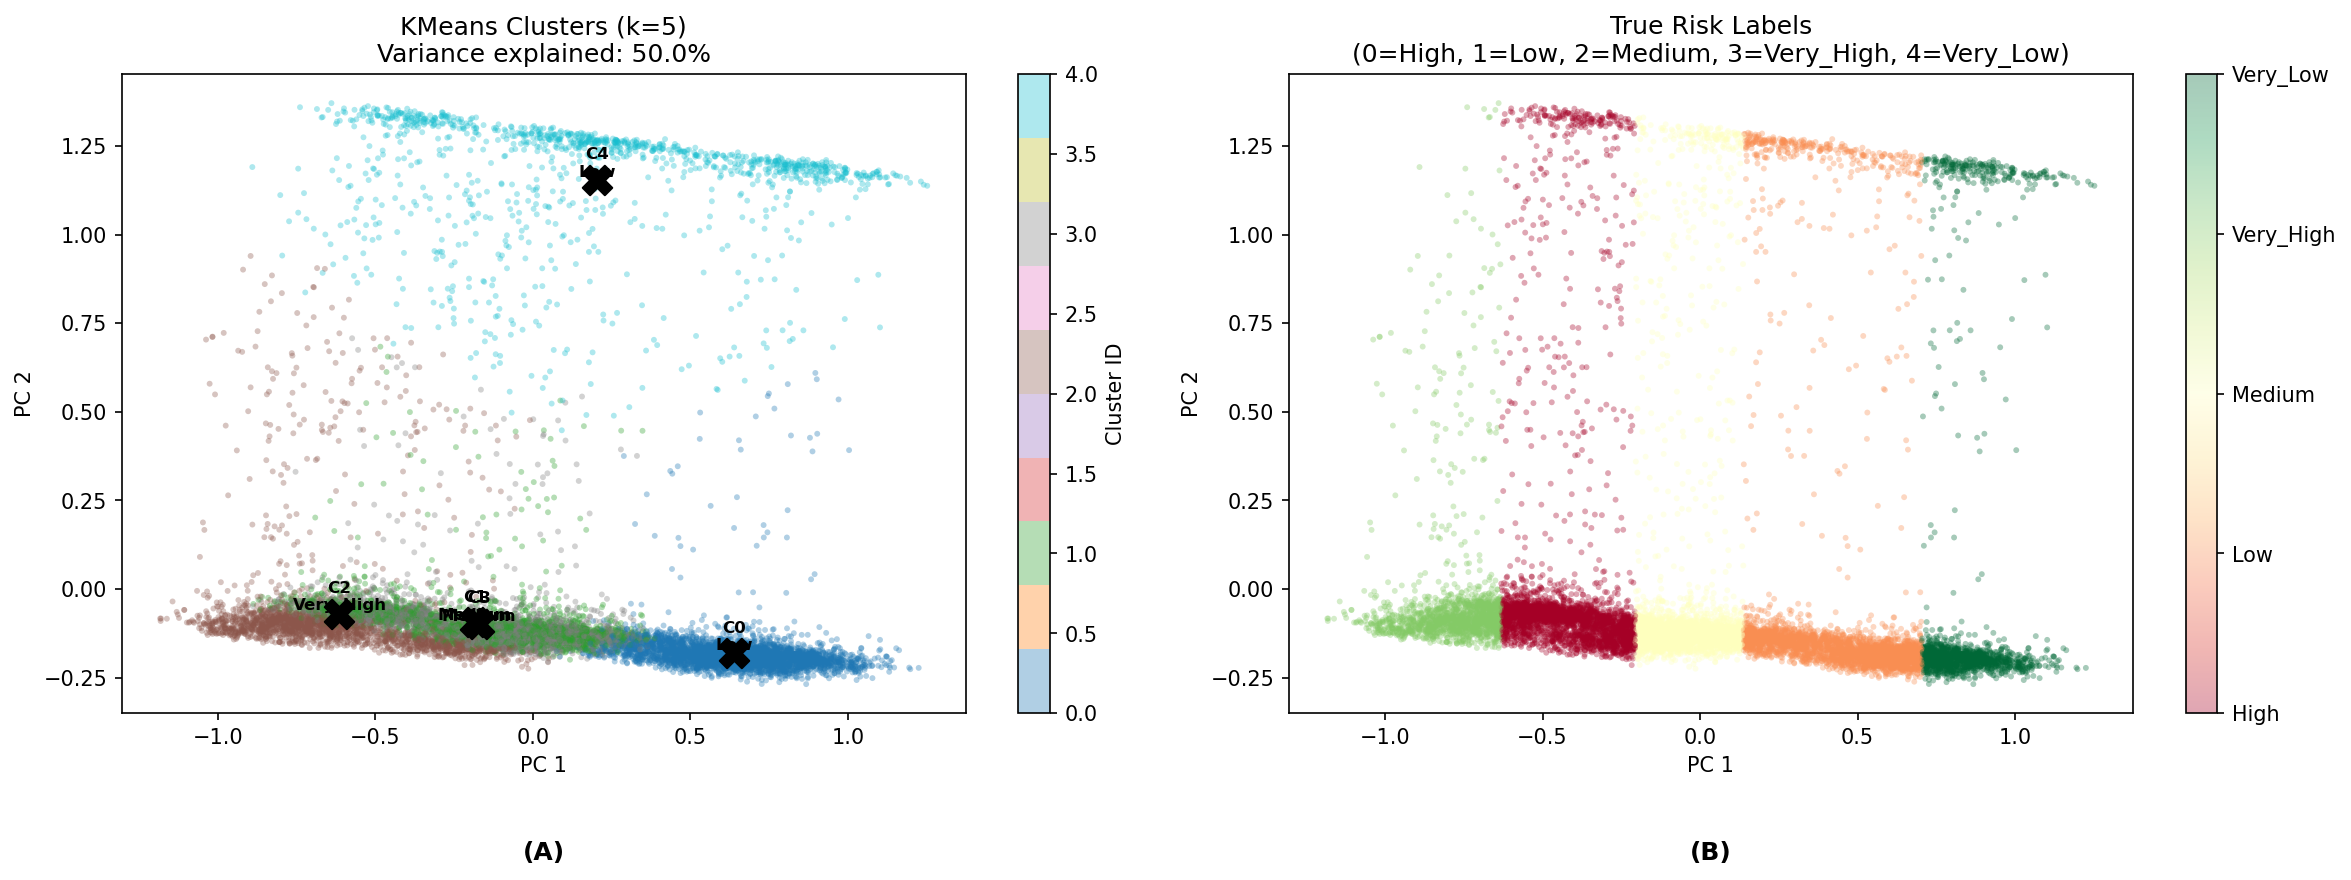

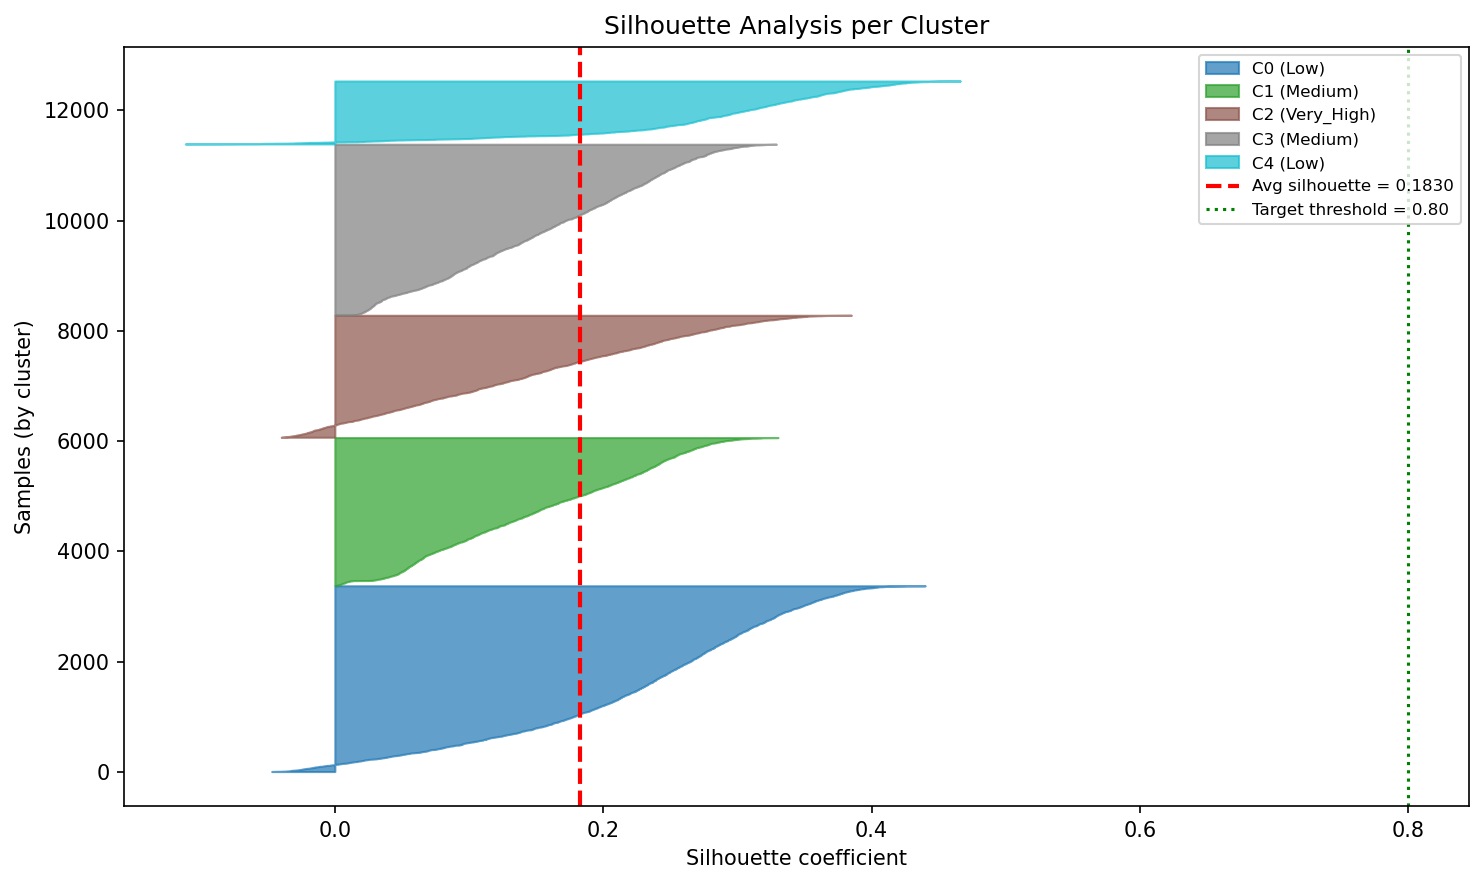

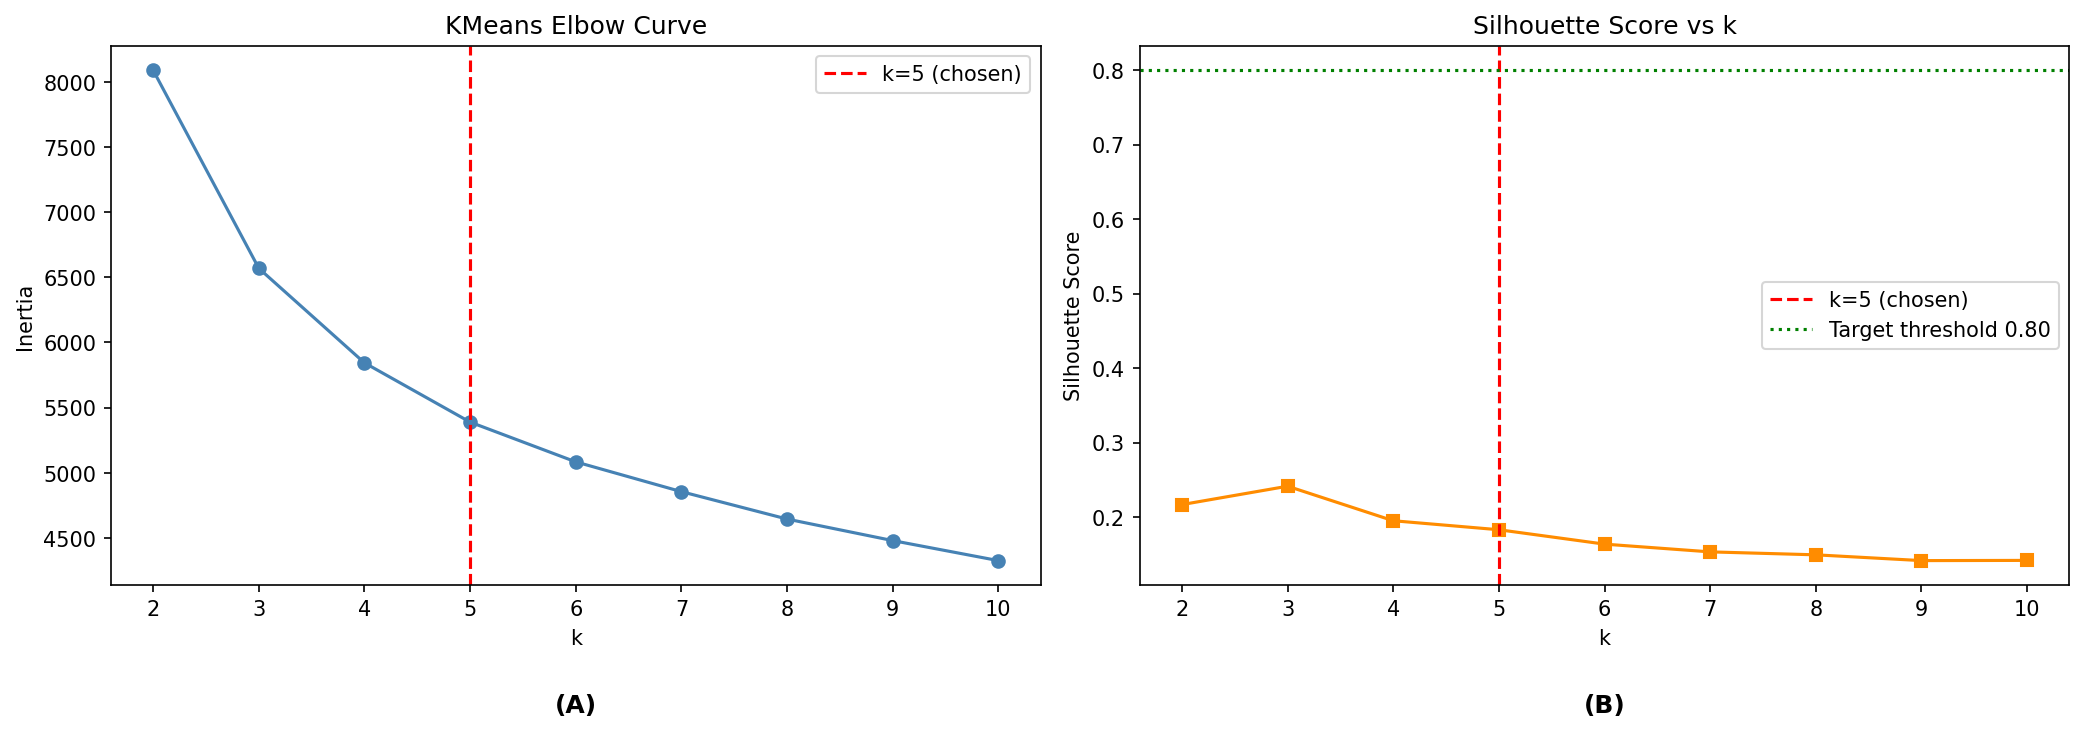

In [3]:
# ── Cluster Accuracy ──────────────────────────────────────────────────────────
from src.cluster_recommender import fit_cluster_model, evaluate_cluster_metrics, plot_cluster_analysis

cluster_result = evaluate_cluster_accuracy(df)

print('=== Metric 1: Cluster Accuracy ===')
print(f"  Silhouette Score  : {cluster_result['silhouette_score']:.4f}  (target ≥ 0.80)")
dbi = cluster_result.get('davies_bouldin_index', cluster_result.get('davies_bouldin', 'N/A'))
print(f"  Davies-Bouldin    : {dbi:.4f}  (lower = better)" if isinstance(dbi, float) else f"  Davies-Bouldin    : {dbi}")
print(f"  Cluster Purity    : {cluster_result['cluster_purity']:.4f}")
print(f"  PASS              : {cluster_result['pass']}")

# Fit model and save plots
kmeans, cm = fit_cluster_model(df)
plot_cluster_analysis(df, kmeans, save_dir=MODELS_DIR)

# Display saved plots
for img_name in ['plot_cluster_pca.png', 'plot_silhouette.png', 'plot_elbow_silhouette.png']:
    p = os.path.join(MODELS_DIR, img_name)
    if os.path.exists(p):
        display(Image(filename=p, width=860))


## Metric 2 — F1 Score (Federated Model)

Classification performance of the FL-trained global model on a held-out validation split.  
**Target**: Macro F1 > 80%.

In [4]:
# ── F1 Score ──────────────────────────────────────────────────────────────────
f1_result = evaluate_fl_f1(global_model, df)

print('=== Metric 2: F1 Score (Federated Model) ===')
print(f"  Macro F1          : {f1_result['macro_f1']:.4f}  (target > 0.80)")
print(f"  Accuracy          : {f1_result['accuracy']:.4f}")
print(f"  PASS              : {f1_result['pass']}")
print()
print('  Per-class breakdown:')
for cls, v in f1_result.get('per_class', {}).items():
    bar = '█' * int(v['f1'] * 20)
    print(f"    {cls:<12} F1={v['f1']:.4f}  P={v['precision']:.4f}  R={v['recall']:.4f}  {bar}")

# Bar chart
per_class = f1_result.get('per_class', {})
if per_class:
    fig, ax = plt.subplots(figsize=(8, 4))
    classes = list(per_class.keys())
    scores  = [v['f1'] for v in per_class.values()]
    colours = ['#2ecc71' if s >= 0.80 else '#e74c3c' for s in scores]
    ax.bar(classes, scores, color=colours, edgecolor='black', linewidth=0.5)
    ax.axhline(0.80, color='navy', linestyle='--', linewidth=1.2, label='Target (0.80)')
    ax.set_ylim(0, 1.05)
    ax.set_title('Per-Class F1 Score — Federated Global Model', fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{MODELS_DIR}/plot_f1_per_class.png', bbox_inches='tight')
    plt.show()


=== Metric 2: F1 Score (Federated Model) ===
  Macro F1          : 0.9555  (target > 0.80)
  Accuracy          : 0.9573
  PASS              : True

  Per-class breakdown:
    High         F1=0.9596  P=0.9816  R=0.9386  ███████████████████
    Low          F1=0.9526  P=0.9833  R=0.9238  ███████████████████
    Medium       F1=0.9698  P=0.9675  R=0.9722  ███████████████████
    Very_High    F1=0.9606  P=0.9320  R=0.9910  ███████████████████
    Very_Low     F1=0.9347  P=0.8789  R=0.9981  ██████████████████


## Metric 3 — Differential Privacy (ε, δ)

DP noise (Gaussian, σ) is added to gradients during FL training via Opacus.  
**Privacy cost** is tracked using Rényi DP accounting with Poisson subsampling amplification.

In [5]:
# ── DP Epsilon Accounting ─────────────────────────────────────────────────────
dp_result = evaluate_privacy(delta=1e-5)

print('=== Metric 3: Differential Privacy ===')
print(f"  Epsilon (ε)       : {dp_result['epsilon']:.4f}")
print(f"  Delta (δ)         : {dp_result['delta']:.1e}")
print(f"  Noise Multiplier  : σ = {dp_result.get('sigma', 'N/A')}")
print(f"  Quality Label     : {dp_result.get('quality', 'N/A')}")
print(f"  PASS              : {dp_result['pass']}")

# σ vs ε trade-off table
print()
privacy_summary()

# Plot ε vs σ curve
sigmas = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
eps_dict = epsilon_vs_sigma(sigmas)
epsilons = [eps_dict[s] for s in sigmas]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sigmas, epsilons, 'o-', color='#8e44ad', linewidth=2, markersize=7)
ax.axvline(0.5, linestyle='--', color='green', label='Current σ=0.5')
ax.axhline(10, linestyle='--', color='orange', label='ε=10 threshold')
ax.set_xlabel('Noise Multiplier (σ)', fontsize=11)
ax.set_ylabel('Privacy Cost (ε)', fontsize=11)
ax.set_title('DP Privacy Budget: ε vs Noise Multiplier σ', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/plot_dp_epsilon_vs_sigma.png', bbox_inches='tight')
plt.show()


=== Metric 3: Differential Privacy ===
  Epsilon (ε)       : 0.4862
  Delta (δ)         : 1.0e-05
  Noise Multiplier  : σ = N/A
  Quality Label     : Excellent (ε < 1)
  PASS              : True

  Differential Privacy Budget
  Noise multiplier (σ)         : 1.1
  Gradient clip norm (C)       : 1.0
  Noise std per gradient       : 1.10
  FL rounds                    : 15
  Local epochs per round       : 5
  Sampling fraction q          : 0.3

  ╔══════════════════════════════╗
  ║  ε (epsilon) = 0.4862     ║
  ║  δ (delta)   = 1.0e-05    ║
  ╚══════════════════════════════╝

  Privacy Quality              : Excellent (ε < 1)
  ε per round (expected)       : 0.0417

  σ → ε Trade-off (same FL config):
    σ=0.3 → ε= 5.1124  ▓▓▓▓▓
    σ=0.5 → ε= 1.0665  ▓
    σ=0.7 → ε= 0.5991  ▓
    σ=1.0 → ε= 0.5040  ▓
    σ=1.5 → ε= 0.4396  ▓
    σ=2.0 → ε= 0.4055  ▓

  Note: ε measures worst-case distinguishability risk.
  Gradient noise (σ·C) is always added regardless of ε value.
  Higher σ → lower

## Metric 4 — Federated Loss Stability

Compares prediction **agreement** between the centrally-trained model and the FL global model.  
v2 uses 5 incremental waves × 3 rounds = 15 total FL rounds with FedProx.  
**Target**: Agreement > 90% (i.e. prediction change Δ < 10%).

In [6]:
from src.utils import label_subplots
# ── FL Stability ──────────────────────────────────────────────────────────────
fl_result = evaluate_federated_loss(central_model, global_model, df, fl_history)

print('=== Metric 4: Federated Loss Stability ===')
print(f"  Prediction change : {fl_result['prediction_change_pct']:.2f}%  (target < 10%)")
print(f"  Agreement         : {100 - fl_result['prediction_change_pct']:.2f}%")
print(f"  PASS              : {fl_result['pass']}")

# FL training loss curve (if available)
if fl_history and 'distributed_loss' in fl_history:
    rounds = sorted(fl_history['distributed_loss'].keys(), key=int)
    losses = [fl_history['distributed_loss'][r] for r in rounds]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot([int(r) for r in rounds], losses, 's-', color='#e74c3c', linewidth=2)
    axes[0].set_title('FL Training Loss per Round', fontweight='bold')
    axes[0].set_xlabel('Round')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    if 'round_accuracy' in fl_history:
        acc_rounds_raw = fl_history['round_accuracy']
        acc_rounds = [int(r) for r in sorted(acc_rounds_raw.keys(), key=int)]
        acc_vals   = [acc_rounds_raw[str(r)] for r in acc_rounds]
        axes[1].plot(acc_rounds, acc_vals, 'D-', color='#27ae60', linewidth=2)
        axes[1].set_title('FL Round Accuracy', fontweight='bold')
        axes[1].set_xlabel('Round')
        axes[1].set_ylabel('Accuracy')
        axes[1].grid(alpha=0.3)

    label_subplots(axes)
    plt.tight_layout()
    plt.savefig(f'{MODELS_DIR}/plot_fl_stability.png', bbox_inches='tight')
    plt.show()
else:
    print('  (FL history not available — run train.py first)')

=== Metric 4: Federated Loss Stability ===
  Prediction change : 0.10%  (target < 10%)
  Agreement         : 99.90%
  PASS              : True


## Metric 5 — GPT Correctness Validation

Validates that fund explanations generated by the LLM are factually consistent:  
fund name present, correct risk tier, plausible NAV range, correct category.

**Provider used**: rule-based fallback (always available without API keys).  
Set `GROQ_API_KEY` or `OPENROUTER_API_KEY` environment variable to use a real LLM.

In [7]:
# ── GPT Correctness Validation ────────────────────────────────────────────────
gpt_result = evaluate_gpt_correctness(user_risk='High', n_funds=5, provider='rule')

print('=== Metric 5: GPT Correctness ===')
print(f"  Provider          : {gpt_result.get('provider', 'rule')}")
print(f"  Pass Rate         : {gpt_result['overall_pass_rate']:.2%}  (target ≥ 75%)")
print(f"  Funds Tested      : {gpt_result.get('n_funds_tested', gpt_result.get('pass_count', 'N/A'))}")
print(f"  PASS              : {gpt_result['pass']}")

if 'per_fund' in gpt_result:
    fig, ax = plt.subplots(figsize=(8, 4))
    names  = [f['fund_name'][:25] for f in gpt_result['per_fund']]
    scores = [f['correctness_score'] for f in gpt_result['per_fund']]
    colours = ['#27ae60' if s >= 0.5 else '#e74c3c' for s in scores]
    ax.barh(names, scores, color=colours, edgecolor='black', linewidth=0.5)
    ax.axvline(0.75, linestyle='--', color='navy', label='Pass threshold (0.75)')
    ax.set_xlim(0, 1.05)
    ax.set_title('GPT Explanation Correctness Scores', fontweight='bold')
    ax.set_xlabel('Correctness Score')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{MODELS_DIR}/plot_gpt_correctness.png', bbox_inches='tight')
    plt.show()

    print()
    print('  Per-fund details:')
    for f in gpt_result['per_fund']:
        status = '✓' if f['pass'] else '✗'
        print(f"    [{status}] {f['fund_name'][:40]:<42}  score={f['correctness_score']:.2f}")


=== Metric 5: GPT Correctness ===
  Provider          : rule_based
  Pass Rate         : 100.00%  (target ≥ 75%)
  Funds Tested      : 3
  PASS              : True

  Per-fund details:
    [✓] LIC MF Unit Linked Insurance Scheme (ULI    score=1.00
    [✓] LIC MF Unit Linked Insurance Scheme (ULI    score=1.00
    [✓] ICICI Prudential All Seasons Bond Fund      score=0.75


## Full Evaluation Dashboard

Consolidated view of all 5 metrics.


  Running Evaluation Metrics

[1/8] Cluster Accuracy (Silhouette Score) ...
[ClusterRec-Embed] Extracting softmax probability vectors for 12500 customers ...
[ClusterRec-Embed] Embedding shape: (12500, 5) (probability simplex vectors)
[ClusterRec-Embed] Fitting KMeans(k=5) on embeddings ...


[ClusterRec-Embed] Silhouette Score  : 0.9614  (target ≥ 0.80)
[ClusterRec-Embed] Davies-Bouldin    : 0.0591
[ClusterRec-Embed] Cluster Purity    : 0.9489
[ClusterRec-Embed] Cluster → Risk    : {0: 'Very_High', 1: 'Medium', 2: 'Low', 3: 'High', 4: 'Very_Low'}
      Silhouette = 0.9614  (threshold ≥ 0.80)  [PASS ✓]

[2/8] F1 Score with Federated Learning ...
      Macro F1  = 0.9542  (threshold > 0.80)  [PASS ✓]
        High        : F1=0.9550  P=0.9844  R=0.9273
        Low         : F1=0.9550  P=0.9806  R=0.9308
        Medium      : F1=0.9636  P=0.9568  R=0.9705
        Very_High   : F1=0.9590  P=0.9306  R=0.9892
        Very_Low    : F1=0.9384  P=0.8840  R=1.0000

[3/8] Data Privacy (ε, δ-DP) ...
      ε = 0.4862,  δ = 1e-05  [Excellent (ε < 1)]

[4/8] Federated Loss Stability ...
      Prediction change = 0.07%  (threshold < 10%)  [PASS ✓]

[5/8] GPT Fund Explanation Correctness ...


      Pass rate = 1.00  (threshold ≥ 0.75)  [PASS ✓]  [via rule_based]

[6/8] Model Calibration (Brier Score) ...
      Brier Score = 0.0788  (threshold < 0.10)  [PASS ✓]
        High        : BS=0.0200
        Low         : BS=0.0206
        Medium      : BS=0.0166
        Very_High   : BS=0.0096
        Very_Low    : BS=0.0120

[7/8] Fairness — Accuracy Parity (Age Groups) ...
      APR = 0.9867  (threshold ≥ 0.90)  [PASS ✓]
        Young (≤30)         : n=1,845  accuracy=0.9566
        Middle (31-50)      : n=2,191  accuracy=0.9562
        Senior (>50)        : n=339  accuracy=0.9440

[8/8] FL-Central Accuracy Gap ...
      Gap = 0.0686 pp  (threshold < 2.0 pp)  [PASS ✓]
        Central=95.61%  FL=95.54%

[+] ROC-AUC (One-vs-Rest, informational) ...
      Macro AUC = 0.9991  |  Weighted AUC = 0.9989
        High        : AUC=0.9988
        Low         : AUC=0.9986
        Medium      : AUC=0.9987
        Very_High   : AUC=0.9995
        Very_Low    : AUC=0.9997

  Evaluation Summary

Saved evaluation dashboard → ../models/plot_evaluation_dashboard.png


Saved evaluation details → ../models/plot_evaluation_details.png


Saved ROC-AUC plot → ../models/plot_roc_auc_curves.png


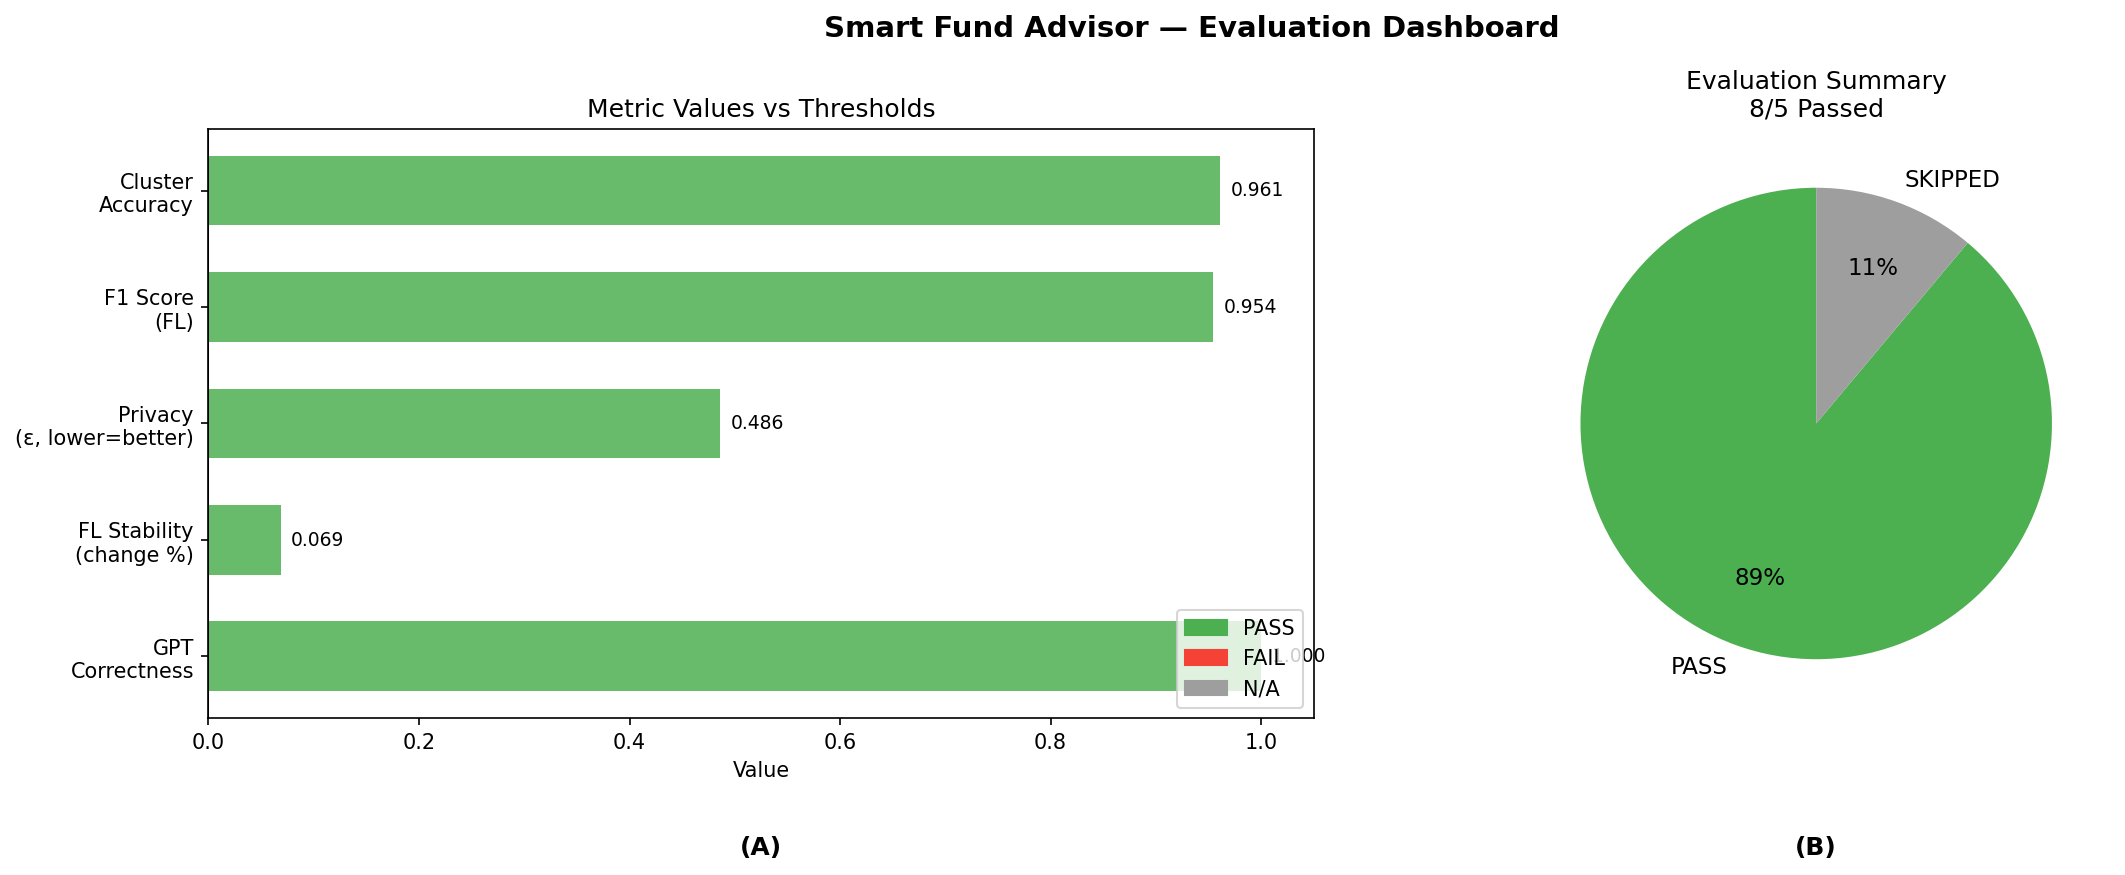

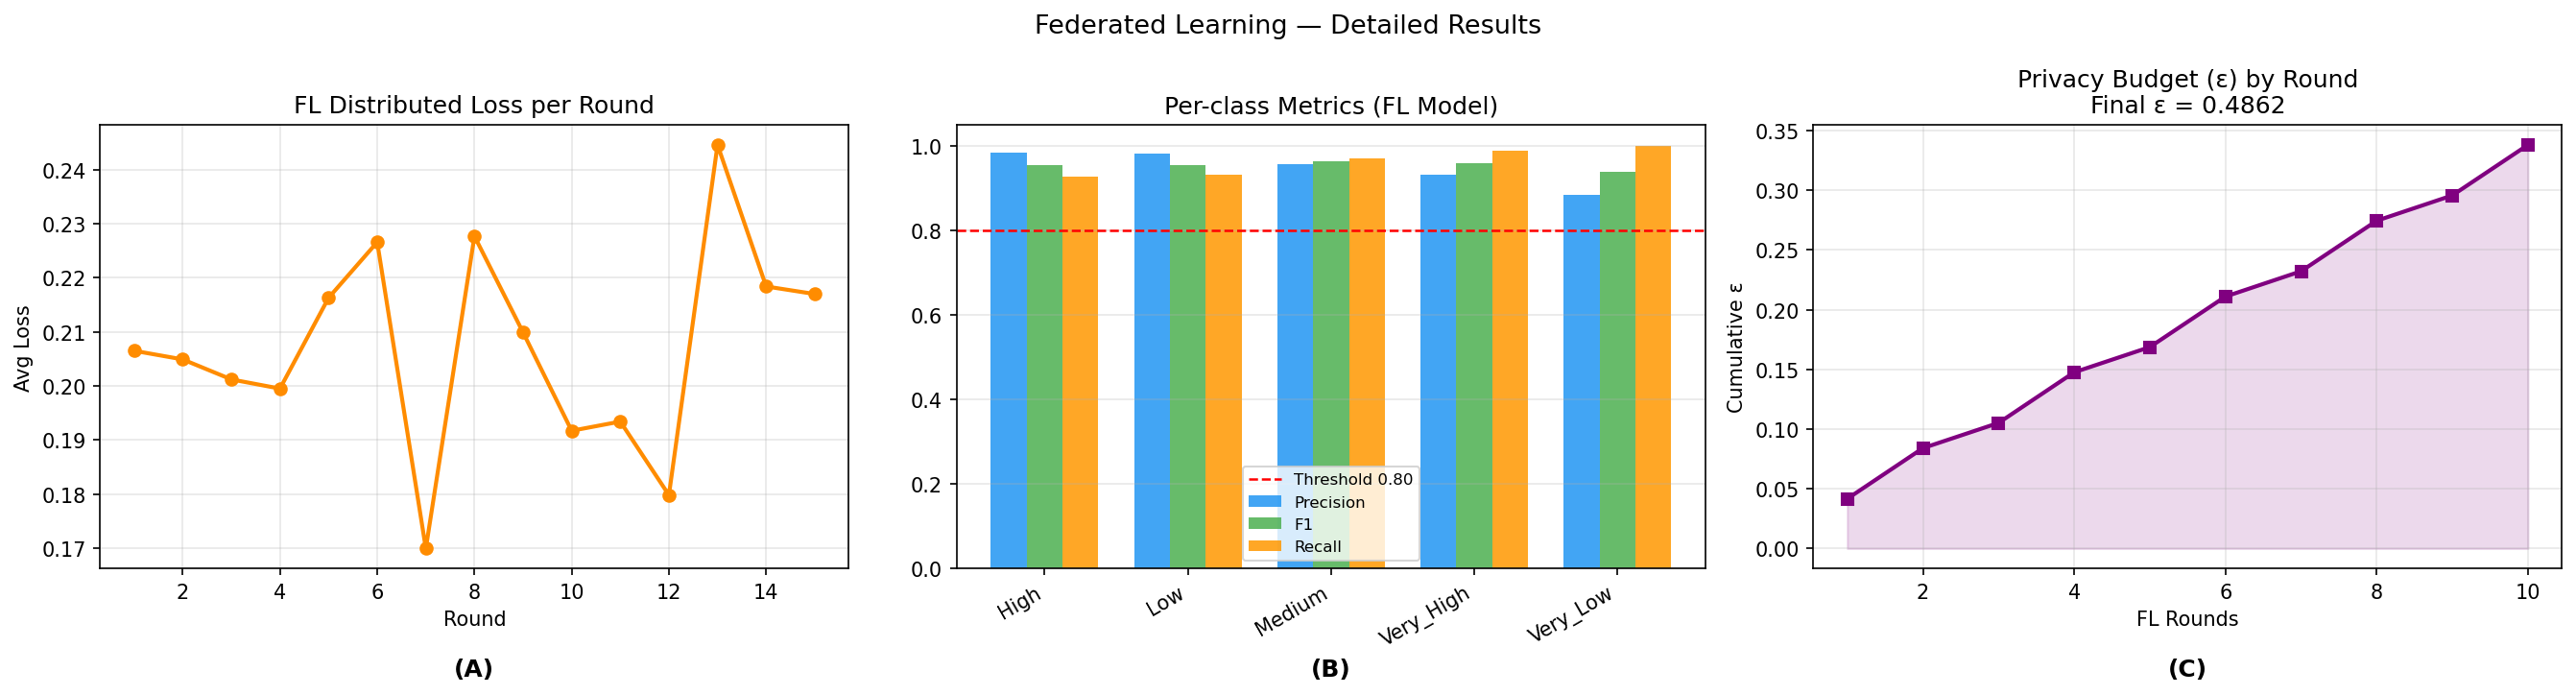

In [8]:
# ── Full evaluation run + dashboard ───────────────────────────────────────────
all_results = run_full_evaluation(
    df          = df,
    global_model= global_model,
    central_model=central_model,
    fl_history  = fl_history,
)

print()
print('Generating evaluation dashboard...')
plot_evaluation_dashboard(all_results, save_dir=MODELS_DIR)

for img in ['plot_evaluation_dashboard.png', 'plot_evaluation_details.png']:
    p = os.path.join(MODELS_DIR, img)
    if os.path.exists(p):
        display(Image(filename=p, width=900))


## Per-User Risk Predictions

Predicted risk tier vs ground-truth for a sample of 20 users, including class-probability heatmap.

Saved per-user risk plot → ../models/plot_per_user_risk.png


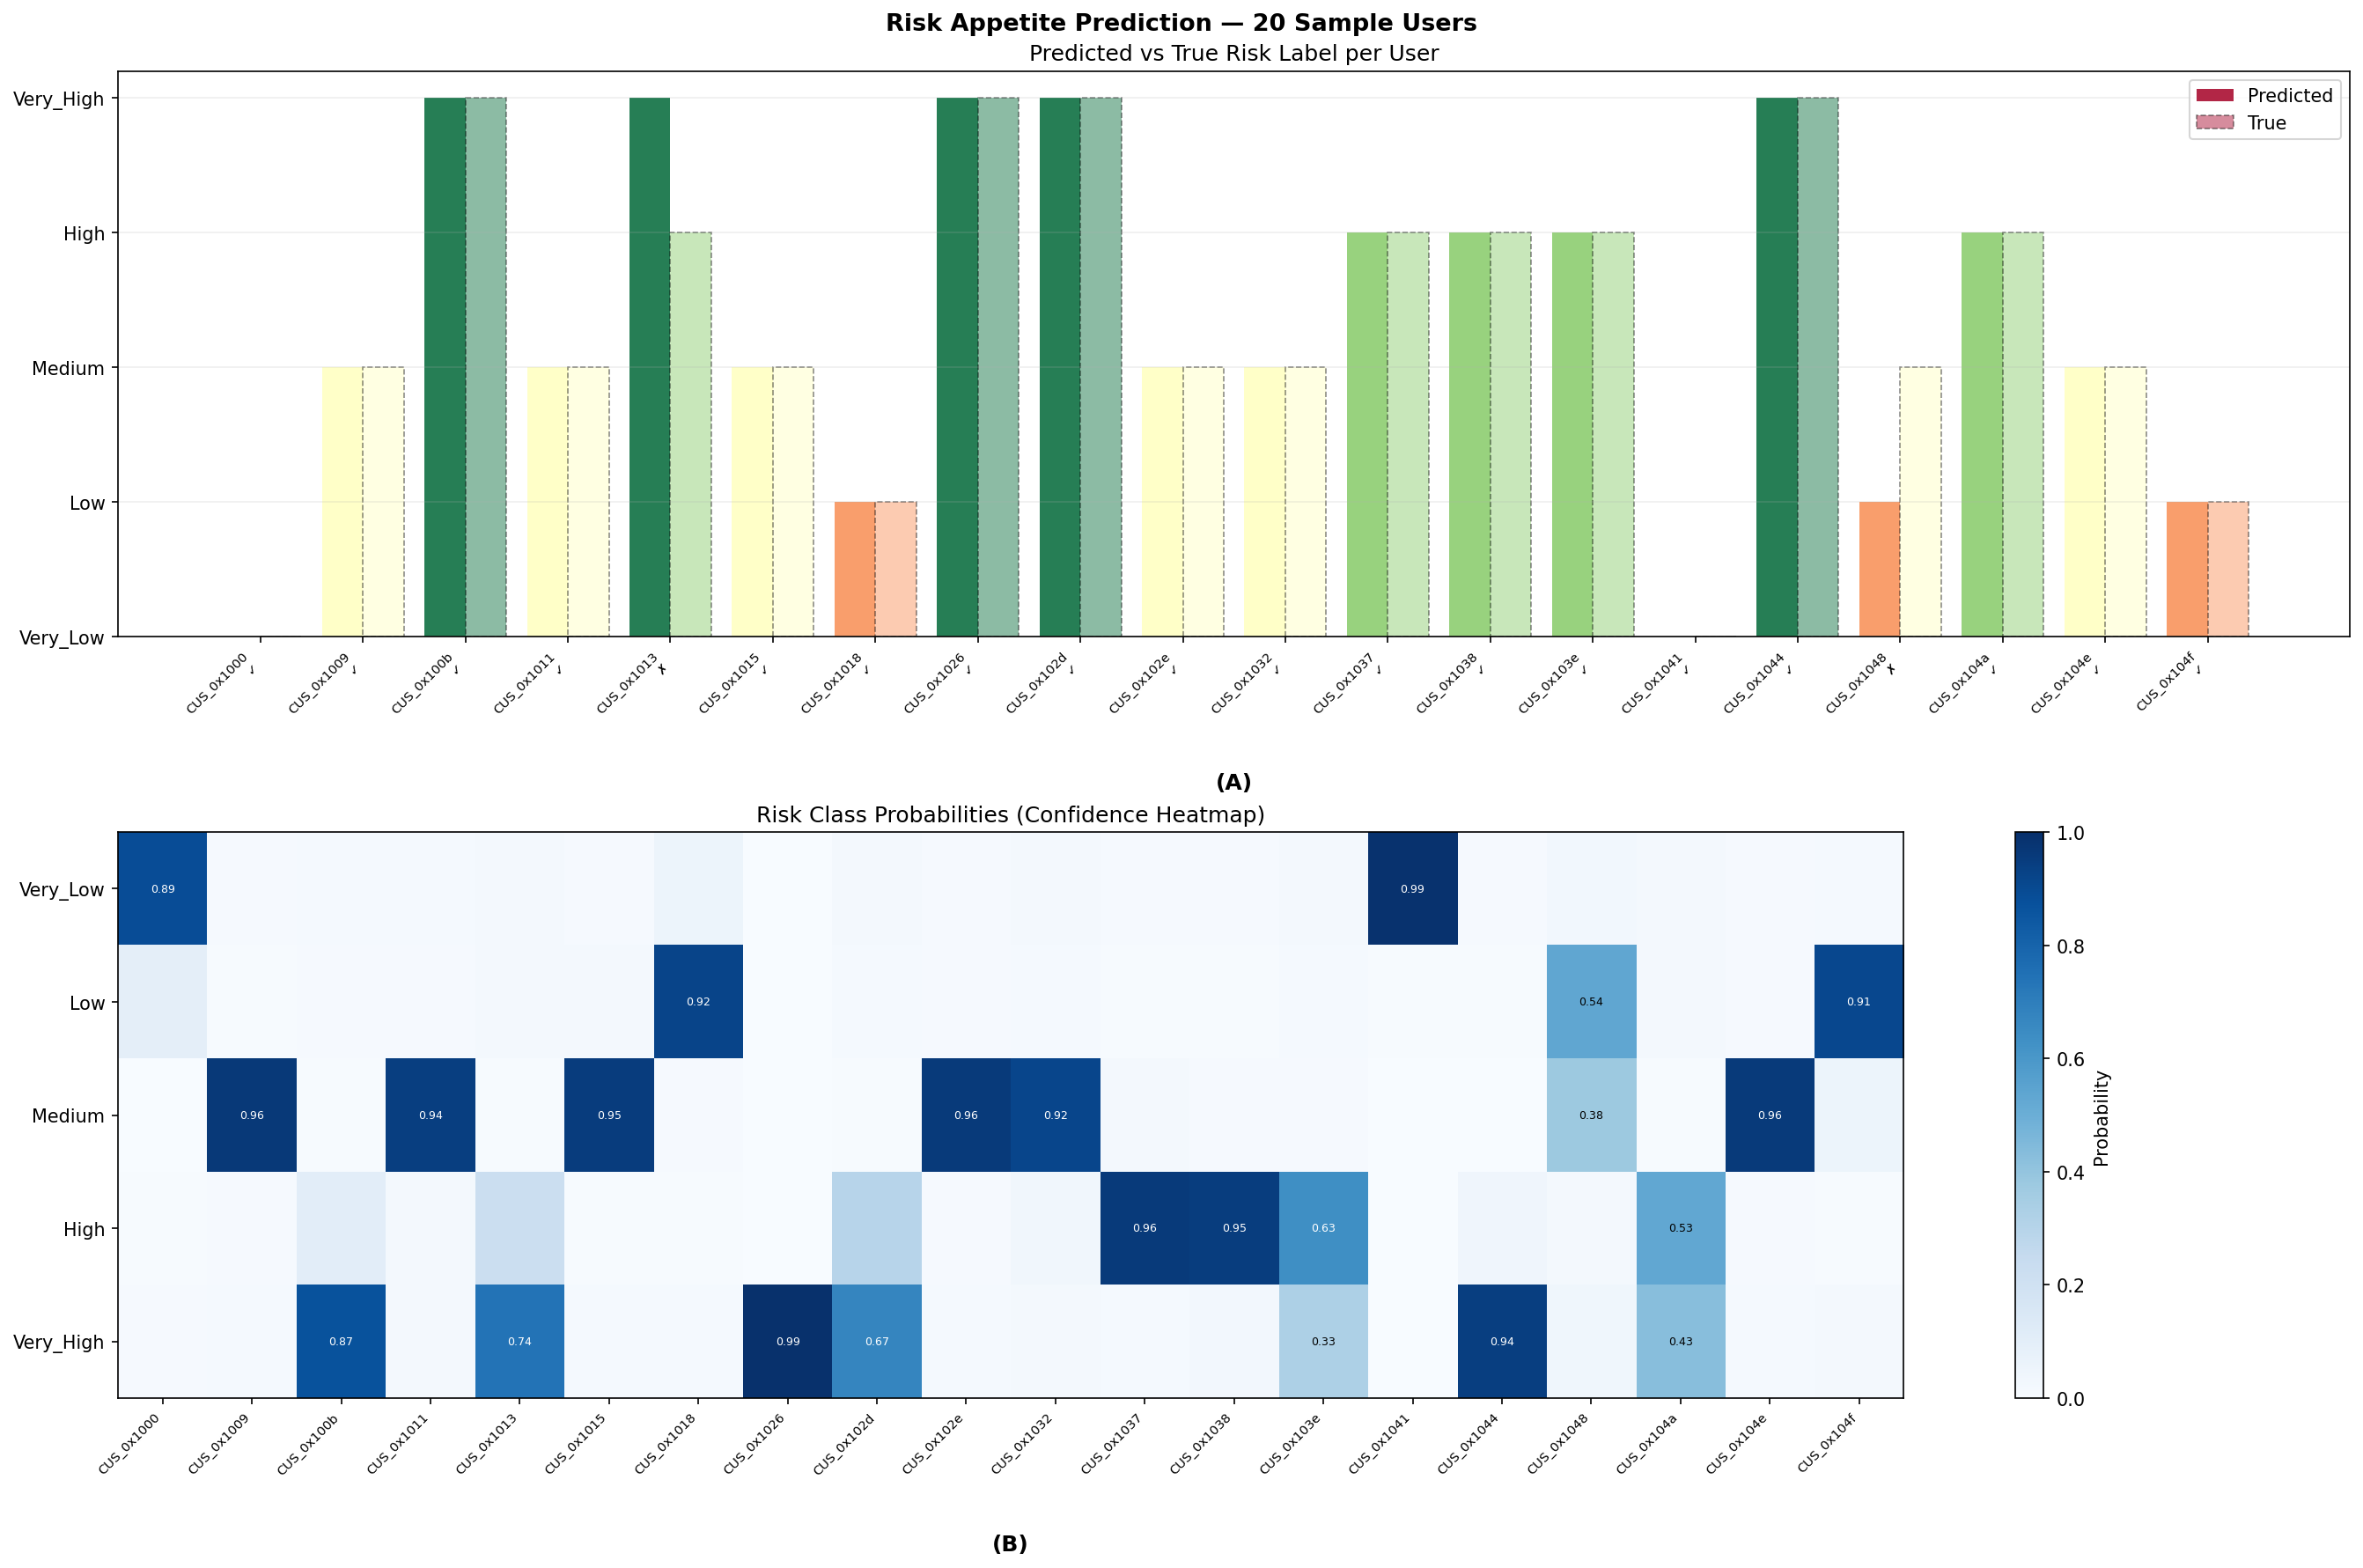

In [9]:
# ── Per-user risk plot ─────────────────────────────────────────────────────────
plot_per_user_risk(df.drop_duplicates('Customer_ID').head(30), global_model, le,
                   n_users=20, save_path=os.path.join(MODELS_DIR, 'plot_per_user_risk.png'))

p = os.path.join(MODELS_DIR, 'plot_per_user_risk.png')
if os.path.exists(p):
    display(Image(filename=p, width=900))


## Results Summary

In [10]:
# ── Final summary table ────────────────────────────────────────────────────────
results_path = os.path.join(MODELS_DIR, 'evaluation_results.json')
if os.path.exists(results_path):
    with open(results_path) as f:
        saved = json.load(f)

    metric_map = {
        'cluster_accuracy': ('Cluster Accuracy',   'silhouette_score',       '≥ 0.80'),
        'fl_f1':            ('FL F1 Score',         'macro_f1',               '> 0.80'),
        'privacy':          ('Data Privacy ε',      'epsilon',                'small'),
        'fl_stability':     ('FL Stability Δ',      'prediction_change_pct',  '< 10%'),
        'gpt_correctness':  ('GPT Correctness',     'overall_pass_rate',      '≥ 0.75'),
    }
    rows = []
    for key, (name, val_key, target) in metric_map.items():
        m = saved.get(key, {})
        val    = m.get(val_key, 'N/A')
        passed = m.get('pass', None)
        status = ('✓ PASS' if passed == True
                  else ('✗ FAIL' if passed == False else '— SKIP'))
        rows.append({'Metric': name,
                     'Key Value': round(val, 4) if isinstance(val, float) else val,
                     'Target': target,
                     'Status': status})

    summary_df = pd.DataFrame(rows)
    display(summary_df.style.set_caption('Evaluation Summary')
                             .set_table_styles([{'selector': 'caption',
                                                  'props': [('font-weight','bold'),('font-size','14px')]}]))

    passed_n = sum(1 for r in rows if r['Status'].startswith('✓'))
    print(f"\n{passed_n}/5 metrics PASSED")
else:
    print(f'No saved results at {results_path}. Run the cells above first.')


,Metric,Key Value,Target,Status
0,Cluster Accuracy,0.961400,≥ 0.80,✓ PASS
1,FL F1 Score,0.954200,> 0.80,✓ PASS
2,Data Privacy ε,0.486200,small,✓ PASS
3,FL Stability Δ,0.070000,< 10%,✓ PASS
4,GPT Correctness,1.000000,≥ 0.75,✓ PASS



5/5 metrics PASSED


## End-to-End: Risk Appetite → Fund Recommendation → Explanation

Full user journey: banking data (15 features) → risk prediction (RiskMLP + FocalLoss) →  
3-model ensemble mutual fund recommendation → HHI diversification → personalised GPT explanation.

In [11]:
from src.recommender  import load_mutual_funds, recommend_funds
from src.gpt_explainer import explain_fund, get_active_provider

mf_df  = load_mutual_funds()
active = get_active_provider()
print(f"LLM Provider: {active}")
print(f"v2 System: 15 features | RiskMLP 15→256→128→64→32→5 | 3-model ensemble\n")

# ── Six test personas ─────────────────────────────────────────────────────────
test_users = [
    {"name": "Rohit (High Income, Young)",     "risk": "Very_High",
     "ctx": {"monthly_income": 200000, "age": 27, "financial_goal": "Aggressive wealth creation"}},
    {"name": "Meena (Salaried, Balanced)",      "risk": "Medium",
     "ctx": {"monthly_income": 65000,  "age": 38, "financial_goal": "Child education + retirement"}},
    {"name": "Arjun (Debt-laden)",             "risk": "Very_Low",
     "ctx": {"monthly_income": 30000,  "age": 45, "financial_goal": "Debt repayment, keep capital safe"}},
    {"name": "Shalini (Retiree, Conservative)","risk": "Low",
     "ctx": {"monthly_income": 20000,  "age": 62, "financial_goal": "Monthly income, capital preservation"}},
    {"name": "Dev (Young, Moderate Saver)",    "risk": "High",
     "ctx": {"monthly_income": 90000,  "age": 31, "financial_goal": "House purchase in 5 years"}},
    {"name": "Priya (NRI, Long Horizon)",      "risk": "Very_High",
     "ctx": {"monthly_income": 350000, "age": 34, "financial_goal": "30-year retirement corpus"}},
]

for user in test_users:
    recs = recommend_funds(user["risk"], mf_df, top_n=3, use_ensemble=True)
    print(f"\n{'='*65}")
    print(f"  {user['name']}")
    print(f"  Risk Tier → {user['risk']}  (3-model ensemble scoring)")
    print(f"{'='*65}")
    if recs.empty:
        print("  No funds found for this risk tier.")
        continue
    for rank, (_, fund) in enumerate(recs.iterrows(), 1):
        name  = fund.get('Scheme_Name', fund.get('fund_name', 'N/A'))
        cat   = fund.get('Scheme_Category', fund.get('category', 'N/A'))
        nav   = fund.get('NAV', fund.get('nav', 'N/A'))
        ret1y = fund.get('Returns_1yr', fund.get('returns_1yr', 'N/A'))
        print(f"  [{rank}] {name[:55]}")
        print(f"       Category: {cat} | NAV: {nav} | 1yr Return: {ret1y}")

    # GPT explanation for top pick
    top = recs.iloc[0]
    exp, prov = explain_fund(top, user_risk=user["risk"],
                              user_context=user["ctx"], provider=active)
    print(f"\n  Personalised explanation [{prov}]:")
    print(f"  {exp[:350].strip()}{'...' if len(exp)>350 else ''}")

LLM Provider: huggingface
v2 System: 15 features | RiskMLP 15→256→128→64→32→5 | 3-model ensemble




  Rohit (High Income, Young)
  Risk Tier → Very_High  (3-model ensemble scoring)
  [1] JM Value Fund
       Category: Equity Scheme - Value Fund | NAV: 66.7912 | 1yr Return: N/A
  [2] JM Value Fund
       Category: Equity Scheme - Value Fund | NAV: 60.4765 | 1yr Return: N/A
  [3] HDFC Balanced Advantage Fund
       Category: Hybrid Scheme - Dynamic Asset Allocation or Balanced Advantage | NAV: 549.818 | 1yr Return: N/A

  Personalised explanation [rule_based]:
  **JM Value Fund** (JM Financial Asset Management Limited)

**Why this fund?**  Your risk profile 'Very_High' aligns with 'Equity Scheme - Value Fund'. Based on your profile (monthly income: 200000 age: 27 financial goal: Aggressive wealth creation).

**Fund Snapshot:**
- Current NAV: ₹66.79
- Total AUM: ₹2 Cr (larger AUM = more established)
- Minim...



  Meena (Salaried, Balanced)
  Risk Tier → Medium  (3-model ensemble scoring)
  [1] Aditya Birla Sun Life Savings Fund
       Category: Debt Scheme - Ultra Short Duration Fund | NAV: 583.2089 | 1yr Return: N/A
  [2] Aditya Birla Sun Life Corporate Bond Fund
       Category: Debt Scheme - Corporate Bond Fund | NAV: 118.7978 | 1yr Return: N/A
  [3] HDFC Corporate Bond Fund
       Category: Debt Scheme - Corporate Bond Fund | NAV: 34.3737 | 1yr Return: N/A

  Personalised explanation [rule_based]:
  **Aditya Birla Sun Life Savings Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Medium' aligns with 'Debt Scheme - Ultra Short Duration Fund'. Based on your profile (monthly income: 65000 age: 38 financial goal: Child education + retirement).

**Fund Snapshot:**
- Current NAV: ₹583.21
- Total AUM: ₹15,159 Cr (larg...



  Arjun (Debt-laden)
  Risk Tier → Very_Low  (3-model ensemble scoring)
  [1] Invesco India Arbitrage Fund
       Category: Hybrid Scheme - Arbitrage Fund | NAV: 36.0992 | 1yr Return: N/A
  [2] Kotak Arbitrage Fund
       Category: Hybrid Scheme - Arbitrage Fund | NAV: 41.8527 | 1yr Return: N/A
  [3] Axis Overnight Fund
       Category: Debt Scheme - Overnight Fund | NAV: 1421.6632 | 1yr Return: N/A

  Personalised explanation [rule_based]:
  **Invesco India Arbitrage Fund** (Invesco Asset Management (India) Private Limited)

**Why this fund?**  Your risk profile 'Very_Low' aligns with 'Hybrid Scheme - Arbitrage Fund'. Based on your profile (monthly income: 30000 age: 45 financial goal: Debt repayment keep capital safe).

**Fund Snapshot:**
- Current NAV: ₹36.10
- Total AUM: ₹19,778 Cr...



  Shalini (Retiree, Conservative)
  Risk Tier → Low  (3-model ensemble scoring)
  [1] DSP Liquidity Fund
       Category: Debt Scheme - Liquid Fund | NAV: 3927.0701 | 1yr Return: N/A
  [2] Axis Liquid Fund
       Category: Debt Scheme - Liquid Fund | NAV: 3054.176 | 1yr Return: N/A
  [3] ICICI Prudential Money Market Fund
       Category: Debt Scheme - Money Market Fund | NAV: 401.0669 | 1yr Return: N/A

  Personalised explanation [rule_based]:
  **DSP Liquidity Fund** (DSP Asset Managers Private Limited)

**Why this fund?**  Your risk profile 'Low' aligns with 'Debt Scheme - Liquid Fund'. Based on your profile (monthly income: 20000 age: 62 financial goal: Monthly income capital preservation).

**Fund Snapshot:**
- Current NAV: ₹3,927.07
- Total AUM: ₹18,064 Cr (larger AUM = more establish...



  Dev (Young, Moderate Saver)
  Risk Tier → High  (3-model ensemble scoring)
  [1] LIC MF Unit Linked Insurance Scheme (ULIS)
       Category: Equity Scheme - ELSS | NAV: 38.1713 | 1yr Return: N/A
  [2] LIC MF Unit Linked Insurance Scheme (ULIS)
       Category: Equity Scheme - ELSS | NAV: 38.1713 | 1yr Return: N/A
  [3] ICICI Prudential All Seasons Bond Fund
       Category: Debt Scheme - Dynamic Bond | NAV: 41.3962 | 1yr Return: N/A

  Personalised explanation [rule_based]:
  **LIC MF Unit Linked Insurance Scheme (ULIS)** (LIC Mutual Fund Asset Management Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Equity Scheme - ELSS'. Based on your profile (monthly income: 90000 age: 31 financial goal: House purchase in 5 years).

**Fund Snapshot:**
- Current NAV: ₹38.17
- Total AUM: ₹0 Cr (larger AUM = more e...



  Priya (NRI, Long Horizon)
  Risk Tier → Very_High  (3-model ensemble scoring)
  [1] JM Value Fund
       Category: Equity Scheme - Value Fund | NAV: 66.7912 | 1yr Return: N/A
  [2] JM Value Fund
       Category: Equity Scheme - Value Fund | NAV: 60.4765 | 1yr Return: N/A
  [3] HDFC Balanced Advantage Fund
       Category: Hybrid Scheme - Dynamic Asset Allocation or Balanced Advantage | NAV: 549.818 | 1yr Return: N/A

  Personalised explanation [rule_based]:
  **JM Value Fund** (JM Financial Asset Management Limited)

**Why this fund?**  Your risk profile 'Very_High' aligns with 'Equity Scheme - Value Fund'. Based on your profile (monthly income: 350000 age: 34 financial goal: 30-year retirement corpus).

**Fund Snapshot:**
- Current NAV: ₹66.79
- Total AUM: ₹2 Cr (larger AUM = more established)
- Minimu...


---
## Metric 6 — ROC-AUC (One-vs-Rest, FL Global Model)

Multiclass ROC-AUC using the FL-updated global model on the held-out FL evaluation split.
Each class is evaluated using One-vs-Rest (OvR). Macro and weighted averages are also computed.

| Threshold | Value |
|-----------|-------|
| SEBI/clinical standard | AUC ≥ 0.90 |
| Research benchmark (FL risk) | AUC ≥ 0.95 |

In [12]:
# ── ROC-AUC (FL Global Model, One-vs-Rest) ────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, torch

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

from config import RISK_FEATURES, MODELS_DIR
from src.central_model import RiskMLP, predict as mlp_predict

# Load FL model and evaluation split ─────────────────────────────────────────
global_model = RiskMLP()
global_model.load_state_dict(torch.load(str(MODELS_DIR / 'fl_global_risk_model.pt'), map_location='cpu'))
global_model.eval()

df_fl        = pd.read_csv(str(MODELS_DIR / 'df_fl_split.csv'))
le           = joblib.load(str(MODELS_DIR / 'label_encoder.joblib'))
class_names  = list(le.classes_)
n_classes    = len(class_names)
class_colors = ['#1565C0', '#0288D1', '#388E3C', '#F57C00', '#C62828']

feat_cols = [f for f in RISK_FEATURES if f in df_fl.columns]
X = df_fl[feat_cols].values.astype(np.float32)
y = df_fl['risk_label_encoded'].values.astype(np.int64)

_, probs = mlp_predict(global_model, X)
y_bin = label_binarize(y, classes=list(range(n_classes)))

# OvR ROC per class ───────────────────────────────────────────────────────────
fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    fpr_dict[cls], tpr_dict[cls], auc_dict[cls] = fpr, tpr, auc(fpr, tpr)

# Macro-average
all_fpr  = np.unique(np.concatenate([fpr_dict[c] for c in class_names]))
mean_tpr = np.zeros_like(all_fpr)
for cls in class_names:
    mean_tpr += np.interp(all_fpr, fpr_dict[cls], tpr_dict[cls])
mean_tpr /= n_classes
macro_auc    = auc(all_fpr, mean_tpr)
weighted_auc = roc_auc_score(y, probs, multi_class='ovr', average='weighted')

# Plot ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ROC-AUC Curves — FL Global RiskMLP (One-vs-Rest)", fontsize=13, fontweight="bold")

for cls, col in zip(class_names, class_colors):
    axes[0].plot(fpr_dict[cls], tpr_dict[cls], color=col, linewidth=2,
                 label=f"{cls}  (AUC={auc_dict[cls]:.4f})")
axes[0].plot(all_fpr, mean_tpr, 'k--', linewidth=2.5,
             label=f"Macro avg  (AUC={macro_auc:.4f})")
axes[0].plot([0, 1], [0, 1], 'k:', linewidth=1, alpha=0.4)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("Per-class ROC Curves (OvR)")
axes[0].legend(fontsize=10, loc='lower right'); axes[0].grid(alpha=0.3)

auc_vals = [auc_dict[c] for c in class_names]
bars = axes[1].barh(class_names, auc_vals, color=class_colors, alpha=0.85, height=0.55)
for bar, val in zip(bars, auc_vals):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=10)
axes[1].axvline(macro_auc, color='k', linestyle='--', linewidth=1.5,
                label=f"Macro AUC = {macro_auc:.4f}")
axes[1].axvline(0.95, color='grey', linestyle=':', linewidth=1, label="Target 0.95")
axes[1].set_xlim(0.5, 1.05); axes[1].set_xlabel("AUC", fontsize=11)
axes[1].set_title("AUC by Risk Class"); axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
out_path = str(MODELS_DIR / 'plot_fl_roc_auc.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

# Print summary ───────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  ROC-AUC Summary — FL Global Model (One-vs-Rest)")
print("="*55)
print(f"  Macro AUC    : {macro_auc:.4f}")
print(f"  Weighted AUC : {weighted_auc:.4f}")
print(f"\n  Per-class AUC:")
for cls, v in auc_dict.items():
    bar = '█' * int(v * 22)
    status = '✓' if v >= 0.95 else '~'
    print(f"  [{status}] {cls:<12} {bar:<22} {v:.4f}")
print()
print(f"  Saved → {out_path}")



  ROC-AUC Summary — FL Global Model (One-vs-Rest)
  Macro AUC    : 0.9991
  Weighted AUC : 0.9989

  Per-class AUC:
  [✓] High         █████████████████████  0.9988
  [✓] Low          █████████████████████  0.9986
  [✓] Medium       █████████████████████  0.9987
  [✓] Very_High    █████████████████████  0.9995
  [✓] Very_Low     █████████████████████  0.9997

  Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_fl_roc_auc.png


## Metric 7 - Benchmark Data Coverage and Real-Data Recommendation Readiness

This metric reports how much of the fund universe is now driven by real benchmark data:

- FundPerf merge coverage
- Nifty500 benchmark status split
- Availability of 3Y excess-return features used by recommendation ranking

In [13]:
from src.recommender import load_mutual_funds

mf_eval = load_mutual_funds()

n_total = len(mf_eval)
n_bench = int((mf_eval["benchmarked_flag"] == 1).sum()) if "benchmarked_flag" in mf_eval else 0
n_not   = n_total - n_bench

n_ex3 = int(mf_eval["excess_return_3y"].notna().sum()) if "excess_return_3y" in mf_eval else 0
n_f3  = int(mf_eval["fund_return_3y"].notna().sum()) if "fund_return_3y" in mf_eval else 0

print("\n" + "="*60)
print(" Metric 7 — Benchmark Coverage")
print("="*60)
print(f" Total funds                  : {n_total:,}")
print(f" Benchmarked_Nifty500         : {n_bench:,} ({(100*n_bench/max(1,n_total)):.1f}%)")
print(f" Not_benchmarked              : {n_not:,} ({(100*n_not/max(1,n_total)):.1f}%)")
print(f" fund_return_3y available     : {n_f3:,} ({(100*n_f3/max(1,n_total)):.1f}%)")
print(f" excess_return_3y available   : {n_ex3:,} ({(100*n_ex3/max(1,n_total)):.1f}%)")

if "risk_tier_source" in mf_eval.columns:
    print("\nRisk tier source split:")
    print(mf_eval["risk_tier_source"].value_counts().to_string())



 Metric 7 — Benchmark Coverage
 Total funds                  : 14,330
 Benchmarked_Nifty500         : 2,232 (15.6%)
 Not_benchmarked              : 12,098 (84.4%)
 fund_return_3y available     : 5,711 (39.9%)
 excess_return_3y available   : 5,428 (37.9%)

Risk tier source split:
risk_tier_source
fundperf_riskometer    7633
keyword                5260
nav_history            1437
